# Decision Tree

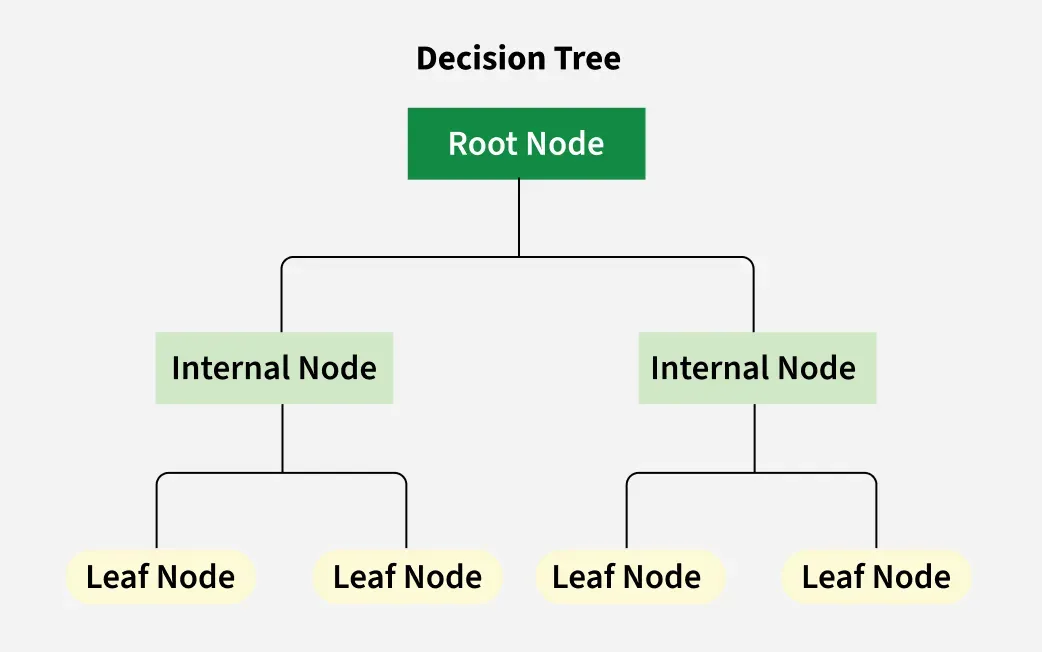

## Impurity

A split which is capable of decreasing the impurity in the child node with respect to the parent node

## Information Gain

Quantitative decrease of impurity in the child Node (Based on Entropy)
    
    - Tells us how useful a question (or feature) is for splitting data into groups.
    - High value when the split is perfectly separated.

Gain $(S,A)$ = $Entropy(S) - \sum_v^A \frac{|S_v|}{|S|} \times Entropy(S_v)$
1. $S$ -> a set of instances
2. $A$ -> an attribute
3. $S_v$ -> the subset of $S$
4. $v$ -> an individual value that the attribute $A$ can take

#### Entropy

The measure of uncertainty of a random variable
    
    1. Represent the impurity of an arbitrary collection os examples 
    
    (Higher = more info)

    2. All yes -> 0 Entropy
    3. Equal number of Yes and No -> High Entropy

Entropy $H(X) = \sum_{i = 1}^n(S_i) \times log_2(S_i)$

Suppose we have a split dataset total of 8, 3 Yes & 5 No:

Entropy $H(X) = [\frac{3}{8} log_2 \frac{3}{8} + \frac{5}{8} log_2 \frac{5}{8}]$

## Gini Index 

One of the most common measures of impurity.

A measure of the inequality among values of a frequency distribution (0 to 1).
- Zero -> Perfect Equality (All values are the same)
- One -> Maximum inequality among values.

Steps

1. Calculate Gini for sub-nodes, using the formula sum of the square of prob. for success and failure 
    
    ($p^2+q^2$)

2. Calculate Gini for split using weighted Gini score of each node of that split.

Formula

$G = 1 - \sum_{i=1}^n{(p_i)^2}$ 

## Cross Entropy

another one of the most common measures of impurity.

$S = -\sum_{i=1}^N{p_ilog_2p_i}$

### Feature Selection

# Implementation

## Classification Tree

In [2]:
# Geeksforgeeks
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [5]:
iris = load_iris()
X = iris.data
y = iris.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [4]:
clf = DecisionTreeClassifier(random_state=1)

In [7]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy score: {accuracy}')

accuracy score: 0.9333333333333333


#### Hyperparameter Tuning

In [12]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ['entropy', 'gini']
}


In [14]:
tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)

grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9666666666666666
DecisionTreeClassifier(max_depth=3, random_state=1)


## Regression Tree